# 01 – Exploratory Data Analysis

This notebook explores the OPSSAT-AD dataset: distributions, correlations, missing values and anomaly prevalence.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.utils.preprocessing import generate_synthetic_dataset, FEATURE_COLUMNS

# Generate (or load) the dataset
df = generate_synthetic_dataset(n_samples=120_000, anomaly_ratio=0.038, seed=42)
print(df.shape)
df.head()

(120000, 22)


,timestamp,temperature_1,temperature_2,temperature_3,voltage_1,voltage_2,voltage_3,current_1,current_2,current_3,...,snr_1,snr_2,pressure_1,pressure_2,gyro_x,gyro_y,gyro_z,mag_x,mag_y,label
0,2024-01-01 00:00:00,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180,0.127840,-0.316243,-0.016801,...,0.777792,0.066031,1.127241,0.467509,-0.859292,0.368751,-0.958883,0.878450,-0.049926,0
1,2024-01-01 00:00:10,-0.184858,-0.680925,1.222546,-0.154529,-0.428328,-0.352134,0.532309,0.365444,0.412733,...,-0.406415,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,-0.824481,0.650593,0
2,2024-01-01 00:00:20,0.743263,0.543163,-0.665501,0.232161,0.116686,0.218689,0.871429,0.223596,0.678914,...,0.631288,-1.457156,-0.319671,-0.470373,-0.638878,-0.275142,1.494941,-0.865831,0.968278,0
3,2024-01-01 00:00:30,-1.682857,-0.334873,0.162766,0.586222,0.711227,0.793347,-0.348725,-0.462352,0.857976,...,-1.133287,-0.919452,0.497161,0.142426,0.690485,-0.427253,0.158540,0.625590,-0.309347,0
4,2024-01-01 00:00:40,0.456792,-0.661909,-0.363037,-0.381738,-1.195840,0.486972,-0.469402,0.012494,0.480747,...,-0.098485,-0.423298,-0.079718,-1.687334,-1.447112,-1.322700,-0.997247,0.399774,-0.905479,0


In [4]:
# ── Label distribution ──────────────────────────────────────────────────────
print('Label counts:')
print(df['label'].value_counts())
print(f'Anomaly ratio: {df["label"].mean():.4f}')

Label counts:
label
0    115440
1      4560
Name: count, dtype: int64
Anomaly ratio: 0.0380


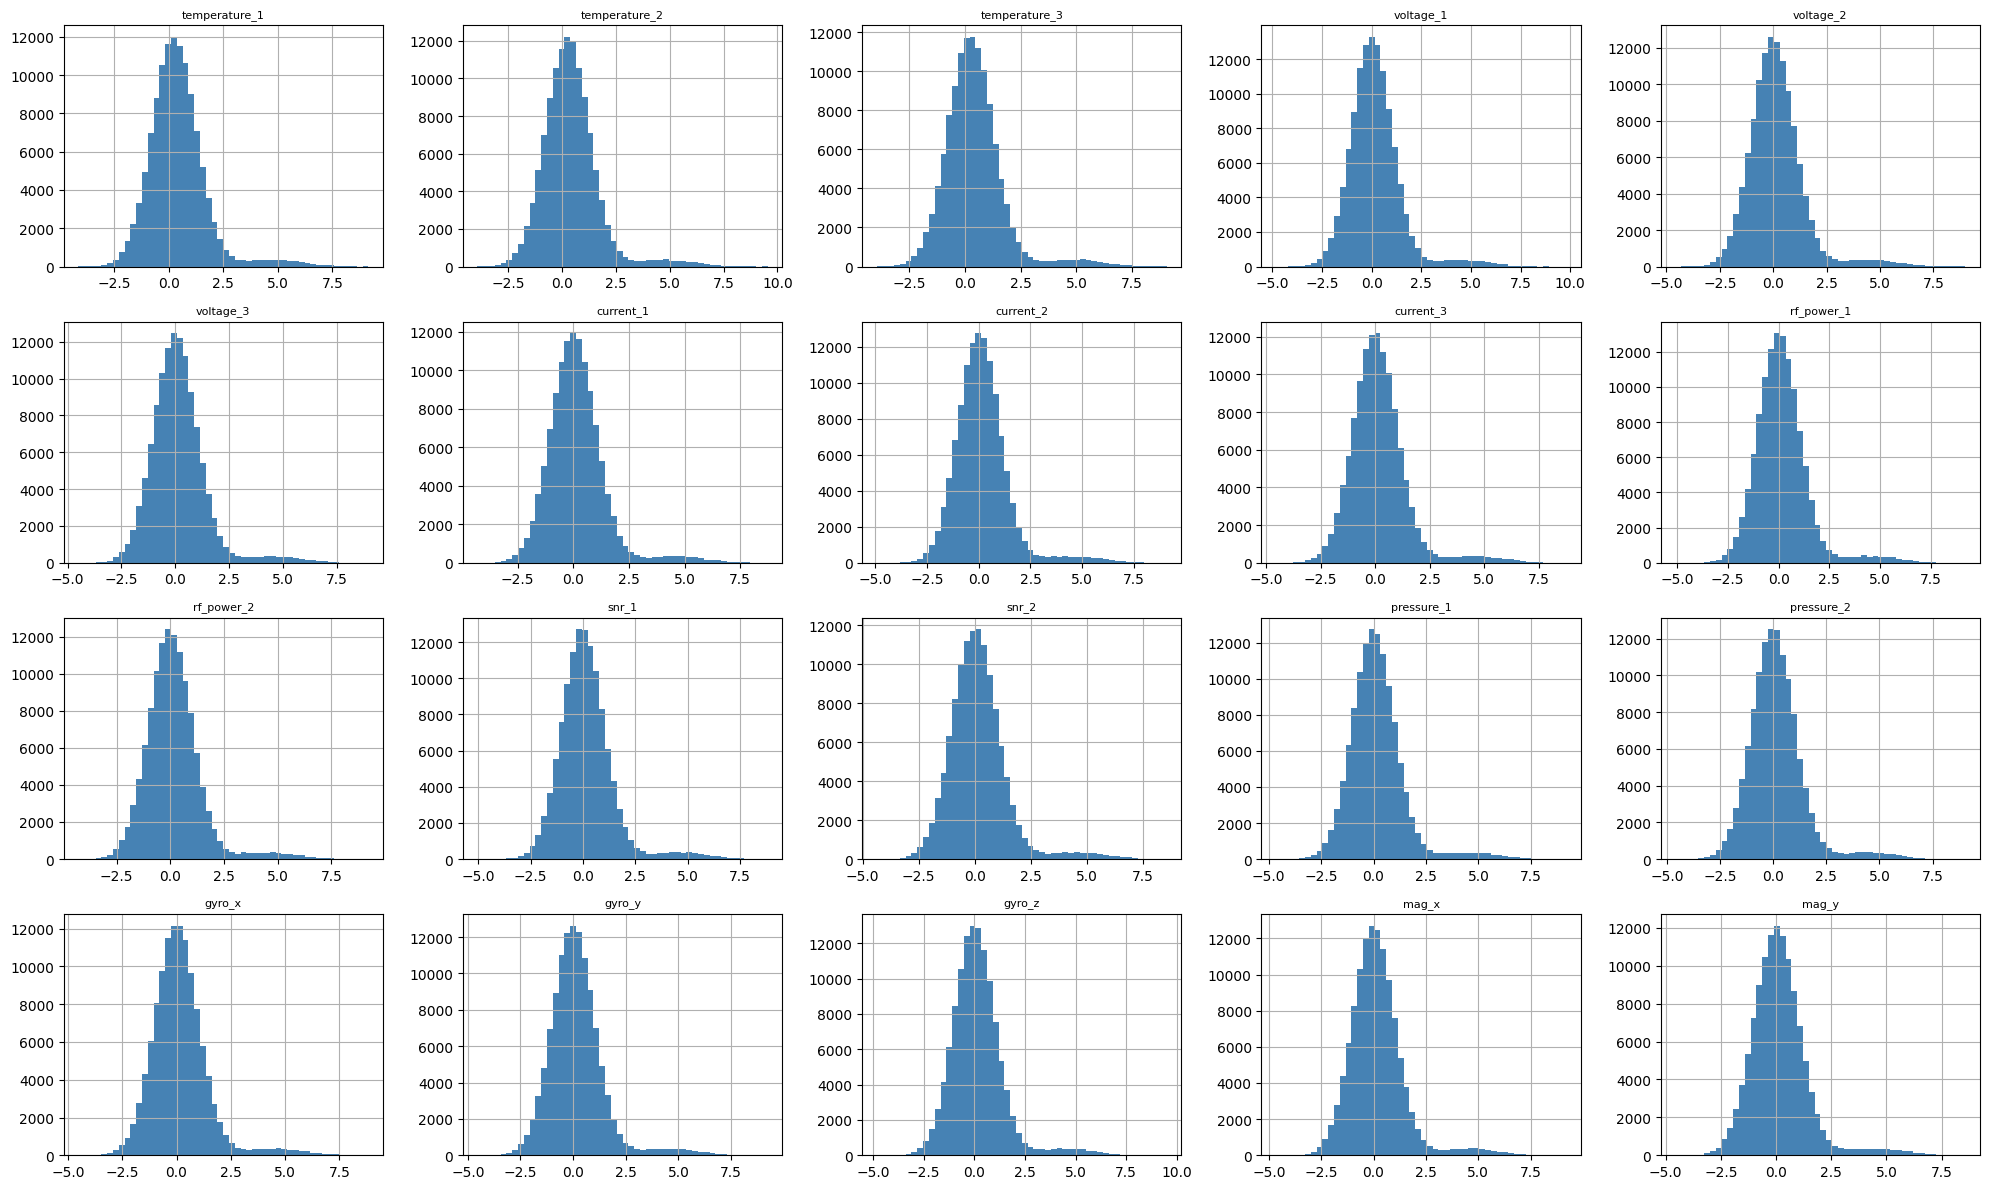

In [6]:
# ── Feature distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
for ax, col in zip(axes.flat, FEATURE_COLUMNS):
    df[col].hist(ax=ax, bins=50, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=8)
plt.tight_layout()
plt.savefig('../results/eda_feature_distributions.png', dpi=100)
plt.show()

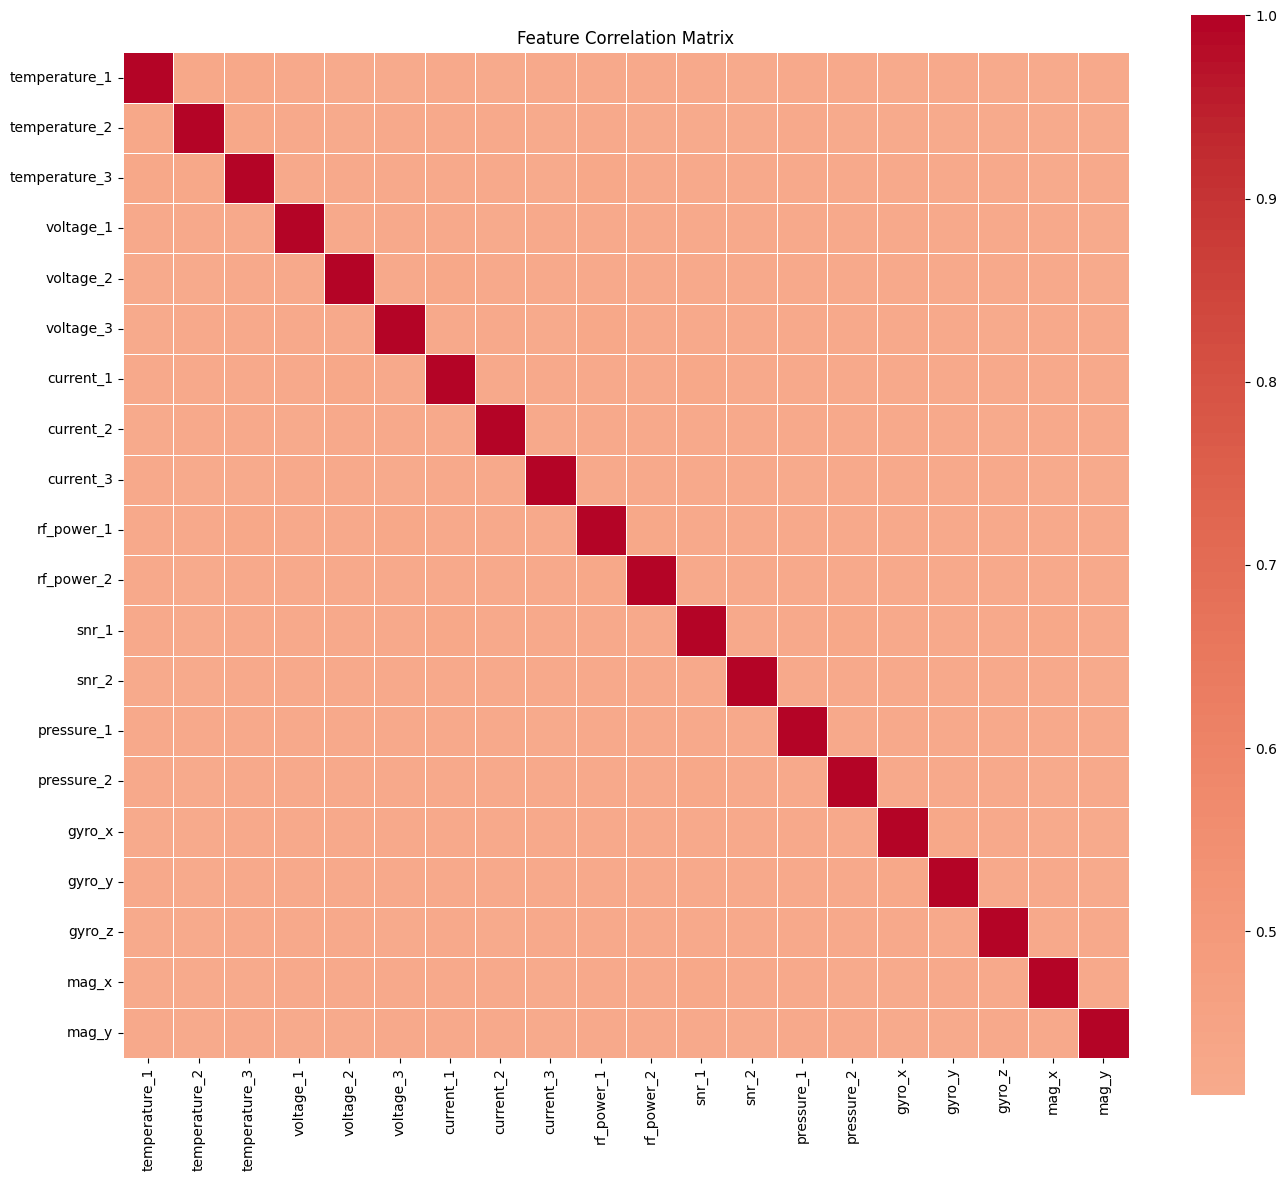

In [7]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr = df[FEATURE_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, square=True,
            linewidths=0.5, annot=False)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/eda_correlation_heatmap.png', dpi=100)
plt.show()

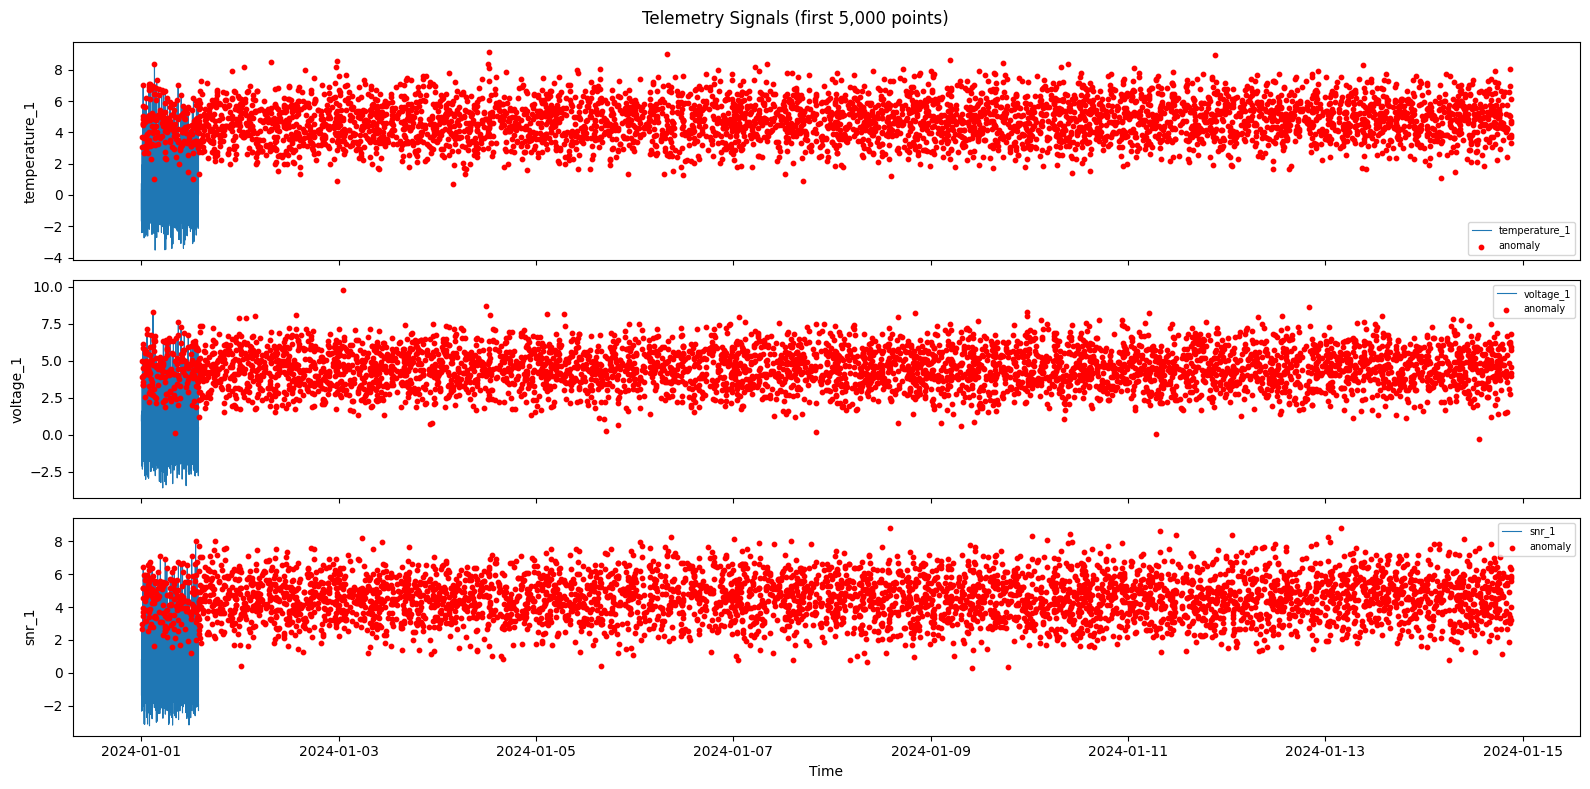

In [8]:
# ── Time series sample plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
for ax, col in zip(axes, ['temperature_1', 'voltage_1', 'snr_1']):
    ax.plot(df['timestamp'][:5000], df[col][:5000], lw=0.8, label=col)
    anomaly_ts = df.loc[df['label'] == 1, 'timestamp'][:5000]
    anomaly_vals = df.loc[df['label'] == 1, col][:5000]
    ax.scatter(anomaly_ts, anomaly_vals, color='red', s=10, zorder=5,
               label='anomaly')
    ax.set_ylabel(col)
    ax.legend(fontsize=7)
axes[-1].set_xlabel('Time')
plt.suptitle('Telemetry Signals (first 5,000 points)')
plt.tight_layout()
plt.savefig('../results/eda_time_series_sample.png', dpi=100)
plt.show()